# 📘 Домашнє завдання №19. Задача кластеризації: DBSCAN, ієрархічна кластеризація

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW19


## 1. Застосувати K-Means

### Необхідно:
- навчити модель K-Means
- використати `n_clusters=3`
- візуалізувати результати кластеризації
- показати центроїди кластерів

---

## 2. Застосувати DBSCAN

### Необхідно:
- підібрати параметри:
  - `eps`
  - `min_samples`
- візуалізувати результати
- визначити:
  - кількість кластерів
  - кількість шумових точок

---

## 3. Застосувати Agglomerative Clustering

### Необхідно:
- використати:
```python
AgglomerativeClustering
```

- спробувати різні `linkage methods`:
  - `ward`
  - `complete`
  - `average`

- порівняти результати

---

## 4. Побудувати дендрограму

### Необхідно:
- побудувати дендрограму
- пояснити:
  - як визначити кількість кластерів
  - що означають великі вертикальні відстані

---

## 5. Обчислити метрики якості

Для кожного алгоритму обчислити:

### Внутрішні метрики:
- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

### Зовнішні метрики:
(оскільки справжні мітки відомі)
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "kagglehub[pandas-datasets]",
    "numpy",
    "matplotlib",
    "scipy",
    "statsmodels",
    "joblib",
    "seaborn",
    "kneed",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [ ]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input data
hm_version = 19

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone data
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

## ✳️ Підготовка датасетів

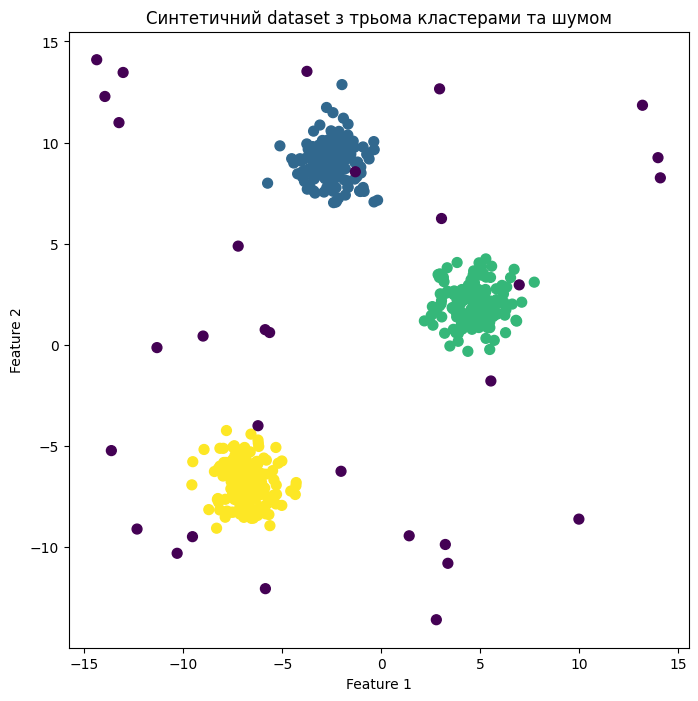

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

# Генерація основних кластерів
X, y_true = make_blobs(
    n_samples=470,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Генерація шуму
np.random.seed(42)

noise = np.random.uniform(
    low=-15,
    high=15,
    size=(30, 2)
)

# Об'єднання кластерів та шуму
X = np.vstack([X, noise])

# Мітки для шуму
noise_labels = [-1] * len(noise)

y_true = np.concatenate([y_true, noise_labels])

# Візуалізація даних
plt.figure(figsize=(8, 8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_true,
    cmap='viridis',
    s=50
)

plt.title("Синтетичний dataset з трьома кластерами та шумом")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()